# 7. Ruido y Significancia — ¿Qué diferencias son reales?

Este notebook existe porque **los notebooks 3, 4 y 6 usaron el estadístico equivocado** para decidir
qué mejoras eran reales, y llegaron a conclusiones erróneas que hay que corregir.

## El error

En los notebooks anteriores, cada vez que un modelo mejoraba al anterior por poco, comparé la ganancia
contra el **desvío entre folds** (~0,00055) y concluí "es ruido". Por ejemplo:

> *"CV AUC = 0,96507 contra 0,96478: +0,00029. La mejora es menor al desvío entre folds, así que no
> hay una ganancia en la que se pueda confiar."*

El problema es que el desvío entre folds mide **qué tan distintos son los folds entre sí** — algunos
tienen filas más difíciles que otros. No mide qué tan distintos son los modelos.

Y como **todos los modelos del episodio se evaluaron sobre exactamente los mismos folds**
(`StratifiedKFold(5, shuffle=True, random_state=42)`), esa dificultad compartida **se cancela al
restar**. Si el fold 3 es difícil, lo es para los dos modelos por igual.

El estadístico correcto es el desvío de la **diferencia** medida sobre las mismas filas: el sigma
*pareado*. Es el mismo argumento que circuló en el foro de la competencia para interpretar el
leaderboard —donde todos los equipos se puntúan sobre las mismas filas de test— y aplica igual a
nuestra validación cruzada.

## Las dos fuentes de ruido

| Fuente | Qué varía | Cómo se mide acá |
|---|---|---|
| **Evaluación** | Qué filas cayeron en la muestra | Bootstrap pareado (sección 2) |
| **Entrenamiento** | Qué modelo salió del ajuste | Reentrenar con varias semillas (sección 4) |

El bootstrap pareado sólo cubre la primera. La segunda es la que menciona el post del foro cuando dice
que dos semillas del mismo modelo intercambian posiciones la mitad de las veces, y es la que falta
medir para cerrar el argumento.

> **Tiempo de ejecución.** Las secciones 1 a 3 tardan unos **10 minutos** (el bootstrap de 200
> resamples sobre 691k filas es lo más pesado) y ya entregan la corrección principal. La sección 4
> son **2 a 2,5 horas** de reentrenamiento, pero está preparada para cortarse y retomarse: guarda cada
> resultado en disco apenas lo obtiene.

**Dataset:** Playground Series S6E8

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata, ttest_rel
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import time
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED    = 42
N_FOLDS = 5

## 1. Predicciones Out-of-Fold de los Modelos del Episodio

In [2]:
train_raw = pd.read_csv("../data/train.csv")
y = train_raw["addicted_label"].values
n = len(y)

oof = {
    "xgb_base":   np.load("../models/3_xgboost_oof.npy"),
    "lgbm":       np.load("../models/4_lightgbm_oof.npy"),
    "red":        np.load("../models/5_red_neuronal_oof.npy"),
    "xgb_optuna": np.load("../models/6_xgboost_optuna_oof.npy"),
}

# El ensamble ganador del notebook 6, reconstruido a partir de los rangos
rangos = {k: rankdata(v) / n for k, v in oof.items()}
oof["ens_3"] = (0.65 * rangos["xgb_optuna"] + 0.20 * rangos["lgbm"] +
                0.15 * rangos["xgb_base"])

print(f"OOF sobre {n:,} filas\n")
for k, v in oof.items():
    print(f"  {k:12s} AUC = {roc_auc_score(y, v):.5f}")

OOF sobre 691,369 filas

  xgb_base     AUC = 0.96478
  lgbm         AUC = 0.96422
  red          AUC = 0.94092
  xgb_optuna   AUC = 0.96507
  ens_3        AUC = 0.96519


## 2. Sigma Absoluto vs Sigma Pareado

Se remuestrean las filas con reposición (bootstrap) y —esto es lo importante— **se usan las mismas
filas remuestreadas para todos los modelos**. Así se puede calcular tanto el desvío del score de cada
modelo por separado como el desvío de la diferencia entre dos.

In [ ]:
B = 200
rng = np.random.default_rng(SEED)
nombres = list(oof)
boot = {k: np.empty(B) for k in nombres}

t0 = time.time()
for b in range(B):
    idx = rng.integers(0, n, n)          # MISMAS filas para todos los modelos
    yb  = y[idx]
    for k in nombres:
        boot[k][b] = roc_auc_score(yb, oof[k][idx])
print(f"{B} resamples en {time.time()-t0:.0f}s\n")

print("Desvio del score individual (sigma absoluto):")
for k in nombres:
    print(f"  {k:12s} {boot[k].std(ddof=1):.5f}")

In [ ]:
comparaciones = [
    ("xgb_optuna", "xgb_base", "el tuning (yo dije: ruido)"),
    ("xgb_base",   "lgbm",     "XGBoost vs LightGBM (yo dije: empate)"),
    ("ens_3",      "xgb_optuna", "ganancia del ensamble de 3"),
    ("xgb_base",   "red",      "referencia: diferencia obvia"),
]

filas = []
for a, b_, etiqueta in comparaciones:
    delta     = roc_auc_score(y, oof[a]) - roc_auc_score(y, oof[b_])
    sigma_abs = np.sqrt(boot[a].std(ddof=1)**2 + boot[b_].std(ddof=1)**2)
    sigma_par = (boot[a] - boot[b_]).std(ddof=1)
    filas.append({"comparacion": f"{a} - {b_}", "que es": etiqueta,
                  "delta": round(delta, 5), "sigma_abs": round(sigma_abs, 5),
                  "sigma_par": round(sigma_par, 5), "z_pareado": round(delta/sigma_par, 1),
                  "reduccion": f"{sigma_abs/sigma_par:.1f}x"})
tabla = pd.DataFrame(filas)

print(f"{'='*100}")
print("SIGMA ABSOLUTO vs SIGMA PAREADO")
print(f"{'='*100}")
print(tabla.to_string(index=False))
print(f"{'='*100}")
print("  z_pareado > 3 => la diferencia es real (no atribuible a que filas tocaron)")

SIGMA ABSOLUTO vs SIGMA PAREADO
          comparacion                                que es   delta  sigma_abs  sigma_par  z_pareado reduccion
xgb_optuna - xgb_base            el tuning (yo dije: ruido) 0.00030    0.00026    0.00003       11.1      9.8x
      xgb_base - lgbm XGBoost vs LightGBM (yo dije: empate) 0.00056    0.00026    0.00004       14.6      6.9x
   ens_3 - xgb_optuna            ganancia del ensamble de 3 0.00011    0.00026    0.00001       10.9     24.5x
       xgb_base - red          referencia: diferencia obvia 0.02386    0.00031    0.00016      150.4      2.0x
  z_pareado > 3 => la diferencia es real (no atribuible a que filas tocaron)


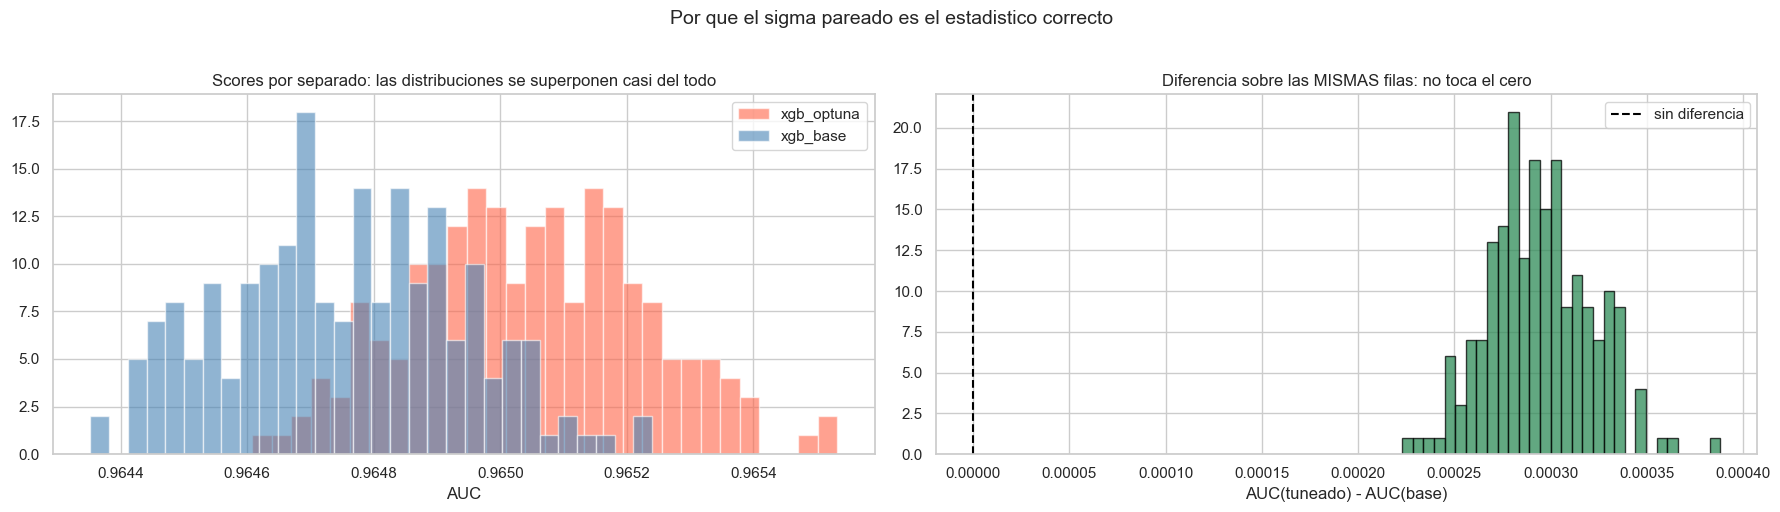

Resamples en que el tuneado gano al base: 200/200


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

a, b_ = "xgb_optuna", "xgb_base"
axes[0].hist(boot[a], bins=30, alpha=0.6, color="tomato", label=f"{a}")
axes[0].hist(boot[b_], bins=30, alpha=0.6, color="steelblue", label=f"{b_}")
axes[0].set_title("Scores por separado: las distribuciones se superponen casi del todo")
axes[0].set_xlabel("AUC")
axes[0].legend()

dif = boot[a] - boot[b_]
axes[1].hist(dif, bins=30, color="seagreen", edgecolor="black", alpha=0.75)
axes[1].axvline(0, color="black", ls="--", lw=1.5, label="sin diferencia")
axes[1].set_title("Diferencia sobre las MISMAS filas: no toca el cero")
axes[1].set_xlabel("AUC(tuneado) - AUC(base)")
axes[1].legend()

plt.suptitle("Por que el sigma pareado es el estadistico correcto", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Resamples en que el tuneado gano al base: {(dif > 0).sum()}/{B}")

## 3. Comparación Pareada por Fold

Otra mirada al mismo asunto, sin bootstrap: calcular la diferencia **dentro de cada fold** y ver si el
signo es consistente. Es más exigente que el bootstrap, porque cada fold es además un modelo
entrenado sobre un subconjunto distinto de los datos.

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = np.empty(n, dtype=int)
for f, (_, val_idx) in enumerate(skf.split(np.zeros(n), y)):
    folds[val_idx] = f

por_fold = []
for f in range(N_FOLDS):
    m = folds == f
    por_fold.append({
        "fold": f + 1,
        "xgb_base":   roc_auc_score(y[m], oof["xgb_base"][m]),
        "xgb_optuna": roc_auc_score(y[m], oof["xgb_optuna"][m]),
    })
df_fold = pd.DataFrame(por_fold)
df_fold["diferencia"] = df_fold["xgb_optuna"] - df_fold["xgb_base"]

print(df_fold.round(5).to_string(index=False))
t, p = ttest_rel(df_fold["xgb_optuna"], df_fold["xgb_base"])
print(f"\n  Media de las diferencias: {df_fold['diferencia'].mean():+.5f}")
print(f"  Desvio de las diferencias: {df_fold['diferencia'].std(ddof=1):.5f}")
print(f"  t pareado = {t:.2f}  (p = {p:.5f}, 4 g.l.)")
print(f"  Folds ganados por el tuneado: {(df_fold['diferencia'] > 0).sum()}/{N_FOLDS}")
print(f"\n  Comparar con el desvio ENTRE folds usado en los notebooks 3/4/6: ~0.00055")
print(f"  Es {0.00055 / df_fold['diferencia'].std(ddof=1):.1f}x mas grande que el desvio relevante.")

 fold  xgb_base  xgb_optuna  diferencia
    1   0.96418     0.96437     0.00020
    2   0.96481     0.96519     0.00037
    3   0.96474     0.96512     0.00038
    4   0.96575     0.96600     0.00024
    5   0.96441     0.96469     0.00028

  Media de las diferencias: +0.00029
  Desvio de las diferencias: 0.00008
  t pareado = 8.33  (p = 0.00113, 4 g.l.)
  Folds ganados por el tuneado: 5/5

  Comparar con el desvio ENTRE folds usado en los notebooks 3/4/6: ~0.00055
  Es 7.0x mas grande que el desvio relevante.


## 4. Ruido de Entrenamiento — ¿Sobrevive a un cambio de semilla?

Todo lo anterior mide **ruido de evaluación**: qué pasa si nos hubieran tocado otras filas. Falta la
otra fuente, que es la que el post del foro señala como dominante: **qué modelo salió del
entrenamiento**. Dos semillas distintas producen árboles distintos (por el submuestreo de filas y de
columnas), y por lo tanto scores distintos.

La pregunta concreta: **¿el tuneado le gana al base con cualquier semilla, o tuvimos suerte con la 42?**

Se reentrenan ambas configuraciones con 3 semillas, sobre los **mismos folds** (el split se mantiene
en `random_state=42`; lo único que cambia es la semilla del booster). Para que esto entre en un tiempo
razonable se usa `learning_rate=0,1` en lugar de 0,05: eso reduce a la mitad la cantidad de árboles y
afecta a **ambas configuraciones por igual**, así que la comparación sigue siendo justa. Los AUC
absolutos van a quedar algo por debajo de los de los notebooks 3 y 6.

> ### Se puede cortar y retomar
> Son 3 semillas × 2 configuraciones = **6 entrenamientos completos de 5 folds**, y medido sobre este
> equipo cada uno tarda entre 20 y 30 minutos: **entre 2 y 2,5 horas en total**.
>
> Por eso la celda **guarda en `../models/7_semillas.csv` apenas termina cada combinación**, en lugar
> de acumular todo en memoria hasta el final. Se puede interrumpir, cerrar el editor, apagar la
> máquina, y al volver a ejecutar la celda retoma desde la combinación que falte.
>
> **Con 2 semillas ya hay un test válido**: si el tuneado gana con 42 y con 202, es evidencia
> razonable de que la ventaja no dependía de la semilla. La tercera lo refuerza, no lo decide. La
> celda de análisis descarta sola las semillas incompletas.

In [ ]:
crudas_num = ["age", "daily_screen_time_hours", "weekend_screen_time", "social_media_hours",
              "gaming_hours", "work_study_hours", "sleep_hours", "notifications_per_day",
              "app_opens_per_day"]
crudas_cat = ["gender", "stress_level", "academic_work_impact"]
test_raw = pd.read_csv("../data/test.csv")


def agregar_derivadas(df):
    d = df.copy()
    componentes = ["social_media_hours", "gaming_hours", "work_study_hours"]
    d["otro_uso"]      = d["daily_screen_time_hours"] - d[componentes].sum(axis=1)
    d["ocio_horas"]    = d["social_media_hours"] + d["gaming_hours"]
    d["screen_sleep"]  = d["daily_screen_time_hours"] / d["sleep_hours"]
    d["social_ratio"]  = d["social_media_hours"] / d["daily_screen_time_hours"]
    d["gaming_ratio"]  = d["gaming_hours"] / d["daily_screen_time_hours"]
    d["weekend_ratio"] = d["weekend_screen_time"] / d["daily_screen_time_hours"]
    d["min_per_open"]  = d["daily_screen_time_hours"] * 60 / d["app_opens_per_day"]
    return d.replace([np.inf, -np.inf], np.nan)


derivadas = ["otro_uso", "ocio_horas", "screen_sleep", "social_ratio",
             "gaming_ratio", "weekend_ratio", "min_per_open"]
train = agregar_derivadas(train_raw)
test  = agregar_derivadas(test_raw)
for col in crudas_cat:
    niveles = sorted(set(train[col].dropna()) | set(test[col].dropna()))
    dtype   = pd.CategoricalDtype(categories=niveles, ordered=False)
    train[col] = train[col].astype(dtype)
X = train[crudas_num + derivadas + crudas_cat]

COMUN = dict(objective="binary:logistic", eval_metric="auc", tree_method="hist",
             enable_categorical=True, n_jobs=-1, n_estimators=4000,
             learning_rate=0.1, early_stopping_rounds=100)

CONFIGS = {
    "base":   dict(max_depth=6, min_child_weight=5,  subsample=0.8,
                   colsample_bytree=0.8,   reg_lambda=1.0),
    "tuneado": dict(max_depth=5, min_child_weight=13, subsample=0.8469,
                   colsample_bytree=0.6757, reg_lambda=0.4489,
                   reg_alpha=0.001045, gamma=0.5520),
}
SEMILLAS = [42, 202, 1337]

print(f"{len(CONFIGS)} configuraciones x {len(SEMILLAS)} semillas x {N_FOLDS} folds "
      f"= {len(CONFIGS)*len(SEMILLAS)*N_FOLDS} entrenamientos")

2 configuraciones x 3 semillas x 5 folds = 30 entrenamientos


In [ ]:
import os

RUTA = "../models/7_semillas.csv"

# Este bucle tarda horas y la memoria del kernel no sobrevive a cerrar el editor,
# asi que cada combinacion se persiste apenas termina. Si se corta a la mitad,
# volver a correr la celda retoma desde la que falte.
previos    = pd.read_csv(RUTA).to_dict("records") if os.path.exists(RUTA) else []
hechos     = {(r["semilla"], r["config"]) for r in previos}
resultados = list(previos)
t_ini      = time.time()

if hechos:
    print(f"Retomando: ya habia {len(hechos)} combinaciones guardadas.\n")

for semilla in SEMILLAS:
    for nombre, params in CONFIGS.items():
        if (semilla, nombre) in hechos:
            print(f"  semilla {semilla:>4} | {nombre:8s} | ya estaba, se saltea")
            continue

        oof_s = np.zeros(n, dtype=np.float32)
        for tr_idx, val_idx in skf.split(X, y):
            modelo = XGBClassifier(**COMUN, **params, random_state=semilla)
            modelo.fit(X.iloc[tr_idx], y[tr_idx],
                       eval_set=[(X.iloc[val_idx], y[val_idx])], verbose=False)
            oof_s[val_idx] = modelo.predict_proba(X.iloc[val_idx])[:, 1]

        resultados.append({"semilla": semilla, "config": nombre,
                           "auc_oof": roc_auc_score(y, oof_s)})
        # El vector OOF completo, por si mas adelante hace falta un test pareado entre semillas
        np.save(f"../models/7_oof_{nombre}_s{semilla}.npy", oof_s)
        pd.DataFrame(resultados).to_csv(RUTA, index=False)
        print(f"  semilla {semilla:>4} | {nombre:8s} | AUC = {resultados[-1]['auc_oof']:.5f} "
              f"| {(time.time()-t_ini)/60:.0f} min | guardado")

df_sem = pd.DataFrame(resultados)
print(f"\nCombinaciones disponibles: {len(df_sem)} de {len(SEMILLAS) * len(CONFIGS)}")
print(f"Tiempo de esta corrida: {(time.time()-t_ini)/60:.1f} min")

In [ ]:
pivot = df_sem.pivot(index="semilla", columns="config", values="auc_oof")
# Solo las semillas que tengan las DOS configuraciones sirven para comparar
completas = pivot.dropna().copy()
completas["diferencia"] = completas["tuneado"] - completas["base"]

print(f"{'='*62}")
print("RUIDO DE ENTRENAMIENTO (semilla del booster)")
print(f"{'='*62}")
print(completas.round(5).to_string())
print(f"{'='*62}")
if len(completas) < len(SEMILLAS):
    print(f"  (analizando {len(completas)} de {len(SEMILLAS)} semillas; el resto aun no esta)")
print(f"  Desvio entre semillas — base:      {completas['base'].std(ddof=1):.5f}")
print(f"  Desvio entre semillas — tuneado:   {completas['tuneado'].std(ddof=1):.5f}")
print(f"  Diferencia media (tuneado - base): {completas['diferencia'].mean():+.5f}")
print(f"  Desvio de la diferencia:           {completas['diferencia'].std(ddof=1):.5f}")
print(f"  Semillas ganadas por el tuneado:   {(completas['diferencia'] > 0).sum()}"
      f"/{len(completas)}")
print(f"{'='*62}")
print("  Lectura: si la diferencia es positiva con todas las semillas y su desvio es")
print("  chico frente a su media, la ventaja del tuning no dependia de la semilla 42.")
print("  Si el desvio entre semillas es del orden del +0.0003, la mejora existe pero")
print("  queda al limite de lo accionable.")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(completas))
ax.plot(x, completas["base"], "o-", color="steelblue", label="base", lw=2)
ax.plot(x, completas["tuneado"], "s-", color="tomato", label="tuneado", lw=2)
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in completas.index])
ax.set_xlabel("Semilla del booster")
ax.set_ylabel("AUC out-of-fold")
ax.set_title("Estabilidad de la ventaja del tuning frente al cambio de semilla")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Nota sobre el Sesgo de Selección

Hay una tercera cosa que ni el bootstrap ni el test de semillas capturan, y que conviene dejar
explícita porque afecta directamente a una conclusión del episodio.

Cuando se eligen los pesos de un ensamble **maximizando el AUC sobre el mismo OOF con el que después
se mide la ganancia**, esa ganancia está inflada por construcción: se eligió el máximo de un conjunto
de opciones ruidosas. El sigma pareado dirá que la diferencia es "real" —y lo es, sobre esas filas—
pero no es una mejora que se pueda esperar fuera de muestra.

Es exactamente lo que pasó con el blend del notebook 4: **+0,00016 en OOF y 0,96634 en el leaderboard,
idéntico al XGBoost solo**.

La distinción con el caso del tuning es importante: ahí los hiperparámetros se eligieron sobre una
**submuestra de 250k filas con 3 folds**, y la evaluación se hizo sobre el OOF completo de 5 folds. No
son conjuntos independientes en sentido estricto, pero la selección no vio el mismo esquema de
evaluación, así que el sesgo es mucho menor.

**Regla que queda para el próximo episodio:** los pesos de un ensamble se eligen en un nivel de
validación anidado, o se aceptan a ciegas (por ejemplo, promedio simple), pero no se optimizan sobre
el mismo conjunto donde se reporta la ganancia.

## 6. Conclusiones

_Pendiente de completar tras ejecutar el notebook._ Lo que conviene registrar:

- **El factor de reducción del sigma al parear.** En la medición preliminar dio ~10x sobre nuestros
  691k filas de OOF; el post del foro reportaba 6-7x sobre las ~59k filas del leaderboard público.
- **El z pareado de cada comparación**, y cuáles de los veredictos de los notebooks 3, 4 y 6 quedan
  corregidos.
- **Cuántos folds y cuántas semillas gana el modelo tuneado.** Es la evidencia más simple de leer: si
  gana 5/5 folds y 3/3 semillas, la ventaja es sólida más allá de cualquier cálculo de sigma.
- **El desvío entre semillas comparado con la ventaja del tuning.** Si el desvío por semilla es del
  mismo orden que el +0,0003, entonces la mejora existe pero está al límite de lo accionable; si es
  mucho menor, es una mejora firme.
- **La lección metodológica**: comparar contra el desvío correcto, y desconfiar de las ganancias
  obtenidas optimizando sobre el mismo conjunto donde se las mide.